In [1]:
%load_ext autoreload
%autoreload 2
import spitap.spec_fit as sf
import lmfit as lm

In [10]:
main_dir = "/home/tbouchet/SPI_SOURCES/obs"
# src_name, spec_dir = 'Crab', '/home/tbouchet/SPI_SOURCES/obs/crab/2023-08-01_2023-10-01_15deg/20_400_35log_SE/fit_0dn_1pi'
# src_name, spec_dir = 'Crab', '/home/tbouchet/SPI_SOURCES/obs/crab/2003-02-19_2003-02-21_15deg/20_600_40log_SE/fit_0dn_1pi'
src_name, spec_dir = 'SWIFT_J1727.8-1613', f'{main_dir}/S1727/2023-09-07_2023-09-08_15deg/20_400_27perso_SE/fit_0di_1pi'
resp = sf.Response(spec_dir, rmf_ebound_ext='EBOUNDS', rmf_matrix_ext='MATRIX', rmf_name='rmf_spi.rmf')
spec_data= sf.SPISpectrum(src_name, 'SPI')
spec_data.import_spectrum(f'{spec_dir}/spectra_{src_name}.fits', rate_col='DFLUX', rate_err_col='DFLUX_ERR')

Imported response with (215x27) channels (N_true x N_detected).
Imported SWIFT_J1727.8-1613 spectrum with 27 channels.


<Axes: xlabel='Reconstructed Energy (keV)', ylabel='True Energy (keV)'>

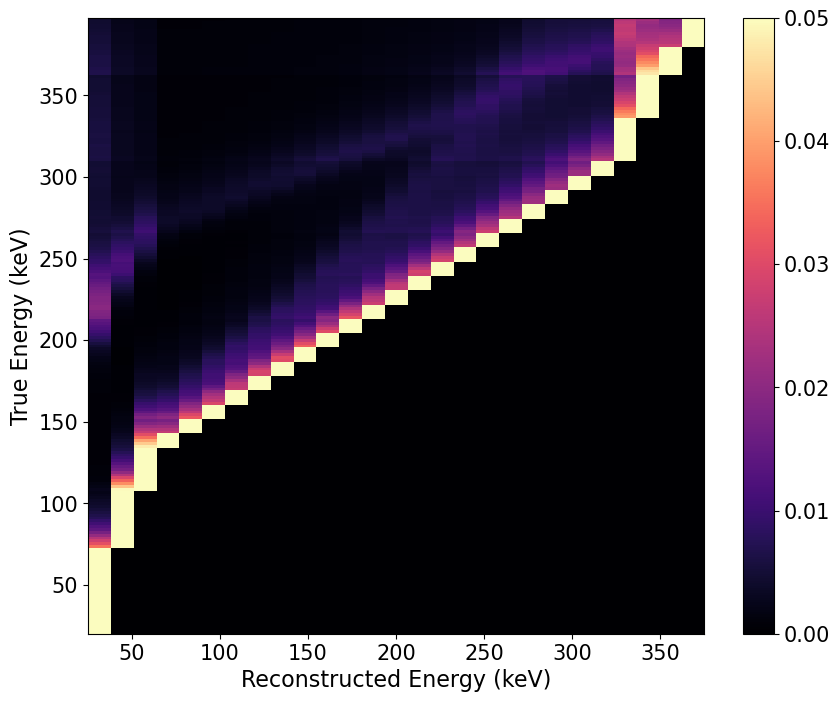

In [11]:
resp.plot_rmf(vmax=.05)

<Axes: xlabel='E (keV)', ylabel='Rate (Counts/s/keV)'>

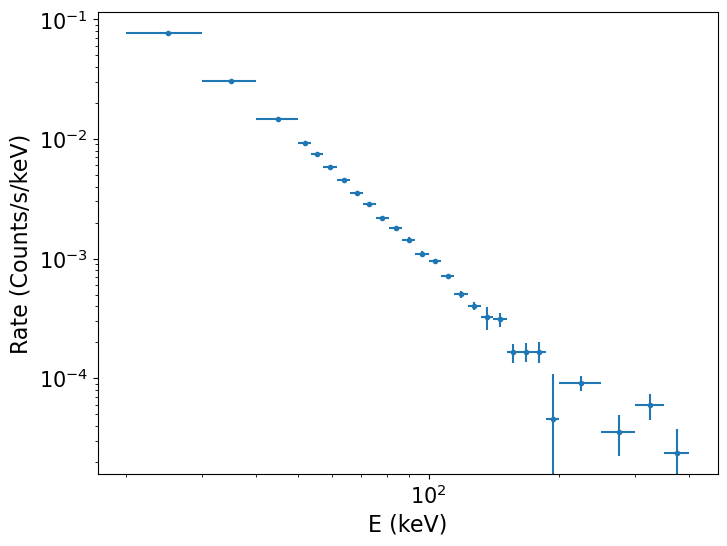

In [12]:
%matplotlib inline
spec_data.import_energy_bands(resp)
spec_data.plot_raw_spec()

In [13]:
e_min_fit, e_max_fit = 50., 400.

lm_params = lm.create_params(
    K = {'value': 10.}, gamma = {'value':2.}
    # K = {'value': 10.}, gamma1 = {'value':2.}, gamma2= {'value':2.3}, Eb={'value':100., 'vary':False} 
    )
fit = sf.Fit(model_name='powerlaw')
# fit = sf.Fit(model_name='bknpl')
result, _ =fit.fit_spec(spec_data, resp, lm_params, e_min_fit, e_max_fit)
result

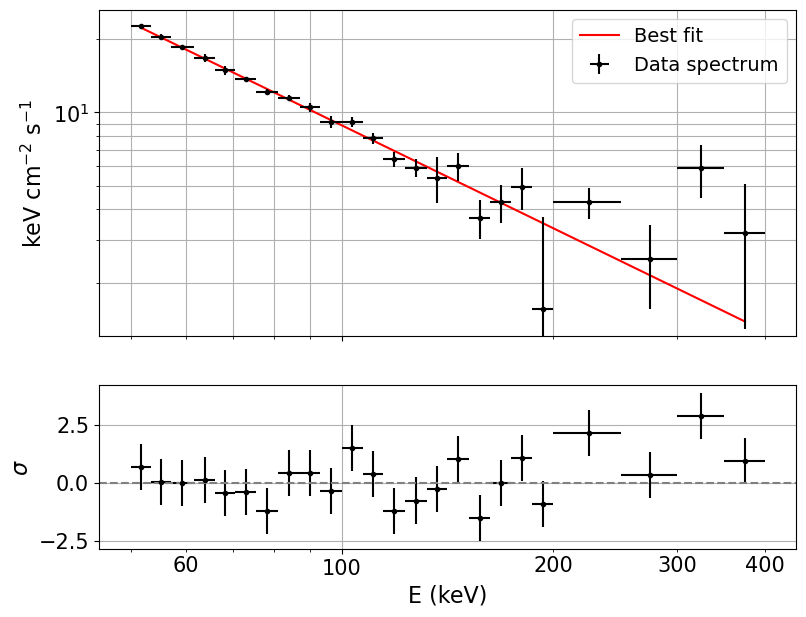

In [14]:
axes=fit.plot_fit(e_min_fit=e_min_fit, e_max_fit=e_max_fit, spec_type='EEFLUX', res_type='RES')
from matplotlib.ticker import LogFormatter
formatter = LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 0.4))
axes[1,0].xaxis.set_major_formatter(formatter)
axes[1,0].xaxis.set_minor_formatter(formatter)
axes[0,0].grid(which='both')
axes[1,0].grid()